# NB5 — Zombie Firm Early-Warning Model
**Zombie Firms Replication** — *Geographical Analysis of the Italian Industrial North*

Trains a set of classifiers to predict zombie firm status one year ahead using observable firm-level financial ratios. Complements the regression analysis (NB3): while the FE regressions identify causal channels, the ML model identifies which financial characteristics are most predictive of future zombification, and quantifies the practical accuracy of early detection.

**Design choices:**
- Target: `zombie_mcgowan` at t+1 (one-year-ahead prediction)
- Features: financial ratios observed at t (no look-ahead)
- Validation: time-based train/val/test split — never random k-fold across years
- Imbalance: class weighting + threshold tuning; SMOTE as robustness check
- Evaluation: AUPRC (primary), ROC-AUC, F1 at optimal threshold, calibration
- Interpretability: SHAP values on the best model

**Outputs:** all figures to `output/figures/`, model metrics to `output/nb5_ml_results.csv`

In [34]:
from pathlib import Path

BASE_DIR   = Path("/Users/leoss/Desktop/Thesis Replication/output")
FIG_DIR    = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

INPUT_FILE     = BASE_DIR / "zombie_panel_classified.parquet"
PRIMARY_ZOMBIE = "zombie_mcgowan"

# Time-based split
TRAIN_YEARS = list(range(2016, 2022))   # 2016–2021
VAL_YEARS   = [2022]
TEST_YEARS  = [2023, 2024]

# ── Robustness flags ──────────────────────────────────────────────────────
# INCLUDE_ICR_LAGS = True  → original spec (icr_w_l1, icr_w_l2 in features)
# INCLUDE_ICR_LAGS = False → leakage-free spec (ICR lags removed)
INCLUDE_ICR_LAGS = False

# Prediction horizons to sweep (years ahead). First entry is the primary model.
HORIZON_SWEEP = [1, 2, 3]
HORIZON = HORIZON_SWEEP[0]   # primary horizon used in single-model training

print(f"Input          : {INPUT_FILE}")
print(f"Train          : {TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]}")
print(f"Val            : {VAL_YEARS}")
print(f"Test           : {TEST_YEARS}")
print(f"Include ICR lags: {INCLUDE_ICR_LAGS}")
print(f"Primary horizon: t+{HORIZON}")


Input          : /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified.parquet
Train          : 2016–2021
Val            : [2022]
Test           : [2023, 2024]
Include ICR lags: False
Primary horizon: t+1


In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, classification_report,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — install with: pip install xgboost")
    print("Falling back to GradientBoostingClassifier")

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
    print("imbalanced-learn available (SMOTE)")
except ImportError:
    HAS_SMOTE = False
    print("imbalanced-learn not found — SMOTE robustness check skipped")
    print("Install with: pip install imbalanced-learn")

try:
    import shap
    HAS_SHAP = True
    print("SHAP available")
except ImportError:
    HAS_SHAP = False
    print("SHAP not found — install with: pip install shap")

NAVY, RED, TEAL = "#1B2A4A", "#C0392B", "#1A6B72"


XGBoost available
imbalanced-learn available (SMOTE)
SHAP available


## 1. Load panel and construct features

Features are constructed at time t to predict zombie status at t+HORIZON.
All features are winsorised at 1% to limit outlier influence.

Lagged ICR values (`icr_w_l1`, `icr_w_l2`) are included **only when
`INCLUDE_ICR_LAGS = True`**. Under the McGowan definition, a firm classified
zombie at t+1 has had ICR < 1 for three consecutive years, so those lags
encode the classification rule directly. Setting `INCLUDE_ICR_LAGS = False`
removes this definitional leakage and tests whether the remaining financial
ratios carry independent predictive content.


In [36]:
df = pd.read_parquet(INPUT_FILE)
print(f"Loaded: {len(df):,} rows | {df['bvd_id'].nunique():,} firms")
print(f"Zombie share (2022): {df[df['year']==2022][PRIMARY_ZOMBIE].mean():.1%}")


Loaded: 672,534 rows | 74,726 firms
Zombie share (2022): 4.4%


In [37]:
def winsorise(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi)

df = df.sort_values(["bvd_id", "year"]).copy()

# ── Core financial ratios (level at t) ───────────────────────────────────
df["log_ta"]        = np.log(df["total_assets"].clip(lower=1))
df["icr_w"]         = winsorise(df["icr"])
df["roa_w"]         = winsorise(df["roa"])
df["inv_rate_w"]    = winsorise(df["investment_rate"])
df["fin_intensity"] = df["financial_expenses"] / df["total_assets"].replace(0, np.nan)
df["fin_int_w"]     = winsorise(df["fin_intensity"])
df["leverage"]      = df["total_liabilities"] / df["total_assets"].replace(0, np.nan)
df["leverage_w"]    = winsorise(df["leverage"])
df["log_emp"]       = np.log(df["employees"].clip(lower=1))
df["emp_growth"]    = df.groupby("bvd_id")["log_emp"].diff()
df["emp_growth_w"]  = winsorise(df["emp_growth"])
df["sales_growth"]  = df.groupby("bvd_id")["turnover"].pct_change().clip(-2, 2)

# ── Lagged values (t-1, t-2) ─────────────────────────────────────────────
for col in ["icr_w", "roa_w", "leverage_w"]:
    df[f"{col}_l1"] = df.groupby("bvd_id")[col].shift(1)
    df[f"{col}_l2"] = df.groupby("bvd_id")[col].shift(2)

# ── Change variables (trend) ──────────────────────────────────────────────
df["d_icr"]      = df.groupby("bvd_id")["icr_w"].diff()
df["d_roa"]      = df.groupby("bvd_id")["roa_w"].diff()
df["d_leverage"] = df.groupby("bvd_id")["leverage_w"].diff()

# ── Firm characteristics ──────────────────────────────────────────────────
df["neg_equity_f"] = df["neg_equity"].fillna(0)
df["log_age"]      = np.log((df["firm_age"].clip(lower=1)))

# ── Zombie entry flag (first year of McGowan classification) ─────────────
# Used as alternative target in robustness section.
df_sorted = df.sort_values(["bvd_id", "year"])
df["zombie_lag"] = df_sorted.groupby("bvd_id")[PRIMARY_ZOMBIE].shift(1)
df["zombie_entry"] = (
    (df[PRIMARY_ZOMBIE] == 1) & (df["zombie_lag"].fillna(0) == 0)
).astype(float)
df.loc[df[PRIMARY_ZOMBIE].isna(), "zombie_entry"] = np.nan

# ── Sector dummies (NACE 2-digit) ─────────────────────────────────────────
nace_dummies = pd.get_dummies(df["nace_2digit"].astype(str), prefix="nace", drop_first=True)
df = pd.concat([df, nace_dummies.astype(float)], axis=1)
nace_cols = list(nace_dummies.columns)

print(f"Feature engineering complete. Shape: {df.shape}")
print(f"Zombie entry events: {df['zombie_entry'].sum():.0f} out of "
      f"{df[PRIMARY_ZOMBIE].sum():.0f} zombie firm-years")


Feature engineering complete. Shape: (672534, 106)
Zombie entry events: 7068 out of 20259 zombie firm-years


## 2. Build prediction dataset

For each firm-year (t), the target is zombie status at t+HORIZON.
All features are observable at t — no look-ahead.

`BASE_FEATURES` excludes or includes ICR lags depending on `INCLUDE_ICR_LAGS`.
The sector dummies are always included.


In [38]:
# Feature list gates on INCLUDE_ICR_LAGS
EXCLUDE_ICR = True   # remove all ICR-derived features (icr_w, d_icr, lags)

_BASE_NO_ICR = [
    "leverage_w", "fin_int_w",
    "inv_rate_w", "emp_growth_w", "sales_growth",
    "log_ta", "log_emp", "neg_equity_f",
    "leverage_w_l1", "leverage_w_l2",
    "d_leverage",
]
_ICR_COLS = ["icr_w", "d_icr", "icr_w_l1", "icr_w_l2"]

if EXCLUDE_ICR:
    BASE_FEATURES = _BASE_NO_ICR
elif INCLUDE_ICR_LAGS:
    BASE_FEATURES = _BASE_NO_ICR + _ICR_COLS
else:
    BASE_FEATURES = _BASE_NO_ICR + ["icr_w", "d_icr"]

ALL_FEATURES = BASE_FEATURES + nace_cols

print(f"ICR excluded entirely : {EXCLUDE_ICR}")
print(f"Base features         : {len(BASE_FEATURES)}  |  Total: {len(ALL_FEATURES)}")
print(f"Features used: {BASE_FEATURES}")

print(f"ICR lags included : {INCLUDE_ICR_LAGS}")
print(f"Base features     : {len(BASE_FEATURES)}  |  Total with sector dummies: {len(ALL_FEATURES)}")
if not INCLUDE_ICR_LAGS:
    print("  NOTE: icr_w_l1, icr_w_l2 excluded — leakage-free specification")

# Forward target at primary HORIZON
df["target"] = df.groupby("bvd_id")[PRIMARY_ZOMBIE].shift(-HORIZON)

ml_df = df[
    df["target"].notna() &
    df[BASE_FEATURES].notna().all(axis=1)
].copy()

train = ml_df[ml_df["year"].isin(TRAIN_YEARS)].copy()
val   = ml_df[ml_df["year"].isin(VAL_YEARS)].copy()
test  = ml_df[ml_df["year"].isin(TEST_YEARS)].copy()

print(f"\nFull ML dataset : {len(ml_df):,} obs | {ml_df['bvd_id'].nunique():,} firms")
print(f"Train           : {len(train):,} obs | zombie rate = {train['target'].mean():.2%}")
print(f"Validation      : {len(val):,}   obs | zombie rate = {val['target'].mean():.2%}")
print(f"Test            : {len(test):,}   obs | zombie rate = {test['target'].mean():.2%}")
print(f"\nClass imbalance ratio: 1:{1/ml_df['target'].mean():.0f} (zombie:non-zombie)")
print(f"Features: {len(ALL_FEATURES)} ({len(BASE_FEATURES)} financial + {len(nace_cols)} sector dummies)")


ICR excluded entirely : True
Base features         : 11  |  Total: 34
Features used: ['leverage_w', 'fin_int_w', 'inv_rate_w', 'emp_growth_w', 'sales_growth', 'log_ta', 'log_emp', 'neg_equity_f', 'leverage_w_l1', 'leverage_w_l2', 'd_leverage']
ICR lags included : False
Base features     : 11  |  Total with sector dummies: 34
  NOTE: icr_w_l1, icr_w_l2 excluded — leakage-free specification

Full ML dataset : 294,569 obs | 63,635 firms
Train           : 193,791 obs | zombie rate = 4.63%
Validation      : 50,190   obs | zombie rate = 3.95%
Test            : 50,588   obs | zombie rate = 3.81%

Class imbalance ratio: 1:23 (zombie:non-zombie)
Features: 34 (11 financial + 23 sector dummies)


## 3. Model training

Four models trained with class weighting to handle imbalance:

1. **Logistic Regression** — interpretable baseline with L2 regularisation
2. **Random Forest** — ensemble of decision trees, robust to outliers
3. **Gradient Boosting / XGBoost** — typically best on tabular imbalanced data
4. **Logistic Regression + SMOTE** — oversampling robustness check (if available)

All models use `class_weight="balanced"` or equivalent. Threshold is tuned on the validation set to maximise F1.

In [39]:
X_train = train[ALL_FEATURES].values
y_train = train["target"].values.astype(int)
X_val   = val[ALL_FEATURES].values
y_val   = val["target"].values.astype(int)
X_test  = test[ALL_FEATURES].values
y_test  = test["target"].values.astype(int)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (XGB): {scale_pos:.1f}")

# ── Model definitions ─────────────────────────────────────────────────────────
scaler = StandardScaler()

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000,
            C=0.1, solver="lbfgs", random_state=42
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        max_depth=8, min_samples_leaf=20,
        n_jobs=-1, random_state=42
    ),
}

if HAS_XGB:
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05,
        max_depth=5, scale_pos_weight=scale_pos,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", early_stopping_rounds=30,
        random_state=42, verbosity=0
    )
else:
    models["Gradient Boosting"] = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        random_state=42
    )

# ── Train ─────────────────────────────────────────────────────────────────────
trained = {}
print("Training models...")
for name, model in models.items():
    print(f"  {name}...", end=" ", flush=True)
    if HAS_XGB and name == "XGBoost":
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
    else:
        model.fit(X_train, y_train)
    trained[name] = model
    print("done")

# SMOTE robustness
if HAS_SMOTE:
    print("  Logistic + SMOTE...", end=" ", flush=True)
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(
        StandardScaler().fit_transform(X_train), y_train
    )
    lr_smote = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
    lr_smote.fit(X_res, y_res)
    trained["Logistic + SMOTE"] = ("smote_prescaled", lr_smote)
    print("done")

print("All models trained.")


scale_pos_weight (XGB): 20.6
Training models...
  Logistic Regression... done
  Random Forest... done
  XGBoost... done
  Logistic + SMOTE... done
All models trained.


## 4. Evaluation

Primary metric: **AUPRC** (area under precision-recall curve). More informative than ROC-AUC under class imbalance because it focuses on the minority (zombie) class. A naive classifier scores AUPRC = zombie prevalence (~4%), so any model above that baseline is adding signal.

Threshold is selected on the **validation set** to maximise F1, then applied to the test set.

In [40]:
def get_proba(name, model, X):
    """Get probability of zombie class, handling SMOTE pipeline."""
    if isinstance(model, tuple) and model[0] == "smote_prescaled":
        X_scaled = StandardScaler().fit(X_train).transform(X)
        return model[1].predict_proba(X_scaled)[:, 1]
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def best_threshold_f1(y_true, proba):
    """Find threshold maximising F1 on given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    idx = np.argmax(f1s[:-1])
    return thresholds[idx], f1s[idx]


results = []
val_probas  = {}
test_probas = {}

for name, model in trained.items():
    p_val  = get_proba(name, model, X_val)
    p_test = get_proba(name, model, X_test)
    val_probas[name]  = p_val
    test_probas[name] = p_test

    # Threshold from validation
    thr, val_f1 = best_threshold_f1(y_val, p_val)

    # Test metrics at that threshold
    y_pred_test = (p_test >= thr).astype(int)

    results.append({
        "Model"          : name,
        "Val AUPRC"      : average_precision_score(y_val,  p_val),
        "Test AUPRC"     : average_precision_score(y_test, p_test),
        "Val ROC-AUC"    : roc_auc_score(y_val,  p_val),
        "Test ROC-AUC"   : roc_auc_score(y_test, p_test),
        "Threshold"      : thr,
        "Val F1"         : val_f1,
        "Test F1"        : f1_score(y_test, y_pred_test),
        "Test Brier"     : brier_score_loss(y_test, p_test),
    })

res_df = pd.DataFrame(results).set_index("Model")
print("\n" + "="*75)
print("MODEL PERFORMANCE")
print("="*75)
print(res_df.round(4).to_string())
print("="*75)
print(f"Naive baseline AUPRC (zombie prevalence): {y_test.mean():.3f}")

res_df.to_csv(BASE_DIR / "nb5_ml_results.csv")
print("Saved: nb5_ml_results.csv")



MODEL PERFORMANCE
                     Val AUPRC  Test AUPRC  Val ROC-AUC  Test ROC-AUC  Threshold  Val F1  Test F1  Test Brier
Model                                                                                                        
Logistic Regression     0.1749      0.1743       0.7707        0.7865     0.7254  0.2559   0.2602      0.2116
Random Forest           0.2381      0.2325       0.8344        0.8379     0.6519  0.3093   0.3046      0.1630
XGBoost                 0.3037      0.3045       0.8657        0.8744     0.8146  0.3562   0.3578      0.1414
Logistic + SMOTE        0.1735      0.1756       0.7708        0.7911     0.7525  0.2543   0.2688      0.2095
Naive baseline AUPRC (zombie prevalence): 0.038
Saved: nb5_ml_results.csv


## 5. Precision-recall and ROC curves

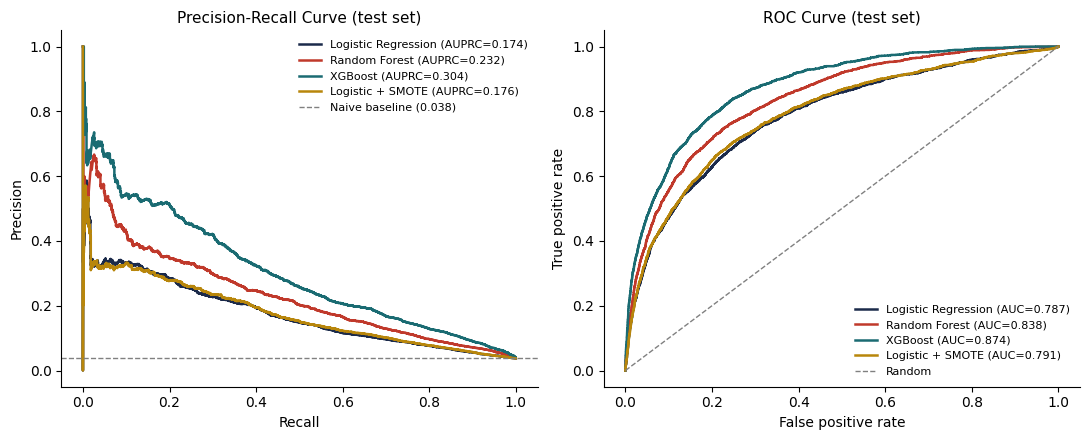

Saved: fig_ml_curves.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
palette = [NAVY, RED, TEAL, "#B8860B", "#6A0572"]

# Precision-recall curves (test set)
ax = axes[0]
for (name, p_test), color in zip(test_probas.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, p_test)
    auprc = average_precision_score(y_test, p_test)
    ax.plot(rec, prec, color=color, lw=1.8,
            label=f"{name} (AUPRC={auprc:.3f})")
ax.axhline(y_test.mean(), color="grey", lw=1, ls="--",
           label=f"Naive baseline ({y_test.mean():.3f})")
ax.set_xlabel("Recall", fontsize=10)
ax.set_ylabel("Precision", fontsize=10)
ax.set_title("Precision-Recall Curve (test set)", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.spines[["top","right"]].set_visible(False)

# ROC curves (test set)
ax = axes[1]
for (name, p_test), color in zip(test_probas.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)
    ax.plot(fpr, tpr, color=color, lw=1.8,
            label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1], color="grey", lw=1, ls="--", label="Random")
ax.set_xlabel("False positive rate", fontsize=10)
ax.set_ylabel("True positive rate", fontsize=10)
ax.set_title("ROC Curve (test set)", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_ml_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_ml_curves.png")


## 6. Calibration

A well-calibrated model assigns predicted probabilities that match empirical zombie rates. Poorly calibrated models are still useful for ranking firms by risk but misleading if probabilities are interpreted as absolute likelihoods.

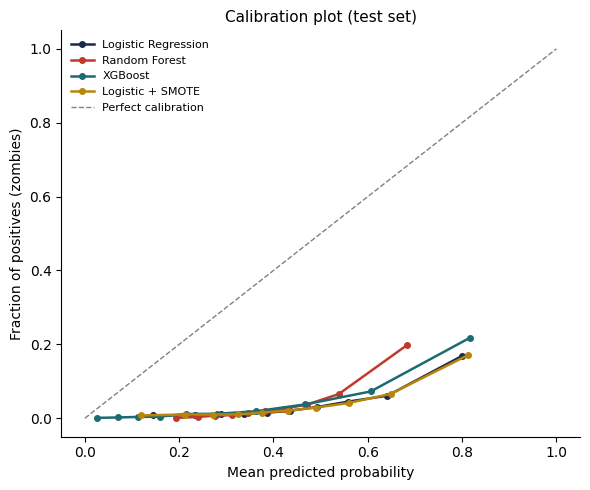

Saved: fig_ml_calibration.png


In [42]:
fig, ax = plt.subplots(figsize=(6, 5))

for (name, p_test), color in zip(test_probas.items(), palette):
    frac_pos, mean_pred = calibration_curve(
        y_test, p_test, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, color=color, lw=1.8,
            marker="o", markersize=4, label=name)

ax.plot([0,1],[0,1], color="grey", lw=1, ls="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability", fontsize=10)
ax.set_ylabel("Fraction of positives (zombies)", fontsize=10)
ax.set_title("Calibration plot (test set)", fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_ml_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_ml_calibration.png")


## 7. SHAP feature importance

SHAP (SHapley Additive exPlanations) decomposes each prediction into the contribution of each feature, giving model-agnostic feature importance that is consistent and locally accurate. Applied to the best-performing model.

Features with large mean |SHAP| values are the strongest predictors of future zombification. The direction (positive/negative SHAP) shows whether high values of the feature increase or decrease zombie probability.

Best model: XGBoost (Test AUPRC=0.304)


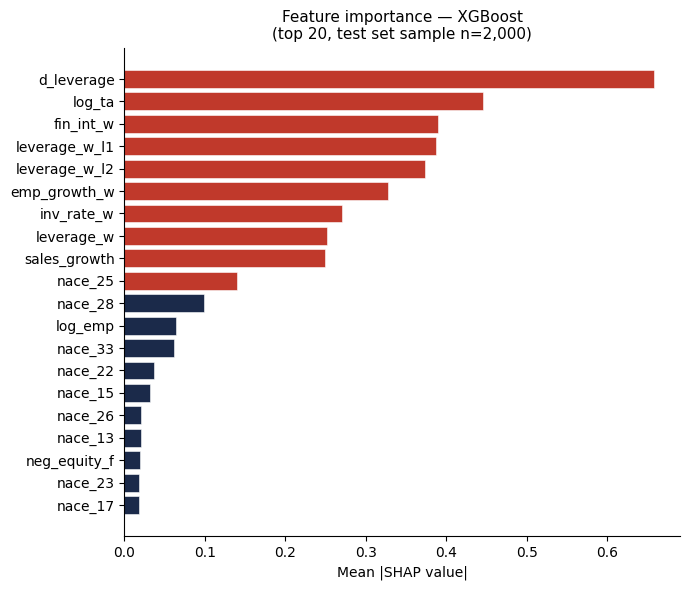

Saved: fig_ml_shap.png
Saved: nb5_shap_importance.csv

Top 10 predictors of future zombie status (XGBoost):
      feature  mean_abs_shap
   d_leverage       0.657310
       log_ta       0.445454
    fin_int_w       0.389821
leverage_w_l1       0.387541
leverage_w_l2       0.373122
 emp_growth_w       0.327429
   inv_rate_w       0.269787
   leverage_w       0.250999
 sales_growth       0.249549
      nace_25       0.140229


In [43]:
if HAS_SHAP:
    best_name  = res_df["Test AUPRC"].idxmax()
    best_model = trained[best_name]
    print(f"Best model: {best_name} "
          f"(Test AUPRC={res_df.loc[best_name, 'Test AUPRC']:.3f})")

    N_SHAP   = min(2000, len(X_test))
    rng      = np.random.default_rng(42)
    idx_shap = rng.choice(len(X_test), N_SHAP, replace=False)
    X_shap   = X_test[idx_shap]

    shap_values = None

    if HAS_XGB and best_name == "XGBoost":
        import json as _j, re as _re

        booster = best_model.get_booster()
        cfg = _j.loads(booster.save_config())
        lmp = cfg["learner"]["learner_model_param"]

        # XGBoost >=1.6 serialises base_score as '[5E-1]' or '[0.5]'.
        # Parse the numeric value regardless of bracket/scientific notation.
        bs_raw = lmp.get("base_score", "0.5")
        bs_clean = _re.sub(r"[\[\]]", "", bs_raw).strip()
        lmp["base_score"] = str(float(bs_clean))
        booster.load_config(_j.dumps(cfg))

        explainer   = shap.TreeExplainer(booster)
        shap_values = explainer.shap_values(X_shap)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

    elif best_name == "Random Forest":
        explainer   = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

    else:
        if hasattr(best_model, "named_steps"):
            clf       = best_model.named_steps["clf"]
            X_shap_sc = best_model.named_steps["scaler"].transform(X_shap)
        else:
            clf, X_shap_sc = best_model, X_shap
        explainer   = shap.LinearExplainer(clf, X_shap_sc)
        shap_values = explainer.shap_values(X_shap_sc)

    if shap_values is not None:
        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        shap_df = (
            pd.DataFrame({"feature": ALL_FEATURES, "mean_abs_shap": mean_abs_shap})
            .sort_values("mean_abs_shap", ascending=False)
            .head(20)
        )

        fig, ax = plt.subplots(figsize=(7, 6))
        colors = [RED if s > shap_df["mean_abs_shap"].median() else NAVY
                  for s in shap_df["mean_abs_shap"]]
        ax.barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1],
                color=colors[::-1], edgecolor="white", linewidth=0.4)
        ax.set_xlabel("Mean |SHAP value|", fontsize=10)
        ax.set_title(
            f"Feature importance — {best_name}\n"
            f"(top 20, test set sample n={N_SHAP:,})", fontsize=11
        )
        ax.spines[["top","right"]].set_visible(False)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "fig_ml_shap.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: fig_ml_shap.png")

        shap_df.to_csv(BASE_DIR / "nb5_shap_importance.csv", index=False)
        print("Saved: nb5_shap_importance.csv")
        print(f"\nTop 10 predictors of future zombie status ({best_name}):")
        print(shap_df.head(10).to_string(index=False))
    else:
        print("SHAP values could not be computed.")
else:
    print("SHAP not available — install with: pip install shap")

## 8. Temporal validation — rolling window

Checks model stability across time by training on all years up to t-1 and evaluating on year t. A stable AUPRC across years means the model generalises; a declining AUPRC near 2023–2024 may reflect the post-COVID regime shift in zombie dynamics.

Rolling validation using: XGBoost

  2020: AUPRC=0.276  ROC-AUC=0.829  (n=48,740, zombie_rate=4.76%)
  2021: AUPRC=0.276  ROC-AUC=0.836  (n=49,543, zombie_rate=4.67%)
  2022: AUPRC=0.295  ROC-AUC=0.860  (n=50,190, zombie_rate=3.95%)
  2023: AUPRC=0.300  ROC-AUC=0.874  (n=50,588, zombie_rate=3.81%)


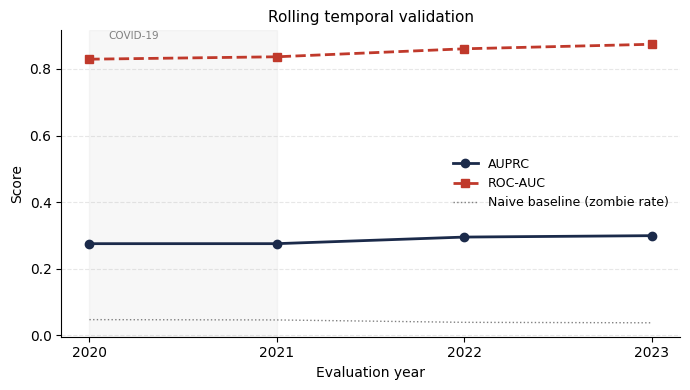

Saved: fig_ml_rolling.png


In [44]:
# Use best model type for rolling validation
best_name = res_df["Test AUPRC"].idxmax()
print(f"Rolling validation using: {best_name}\n")

rolling_years = list(range(2019, 2025))   # need at least 2 train years before first eval
rolling_results = []

for eval_yr in rolling_years:
    train_yrs = [y for y in range(2016, eval_yr) if y in ml_df["year"].unique()]
    if len(train_yrs) < 2:
        continue

    tr = ml_df[ml_df["year"].isin(train_yrs)]
    ev = ml_df[ml_df["year"] == eval_yr]
    if len(ev) == 0 or ev["target"].sum() < 5:
        continue

    Xtr, ytr = tr[ALL_FEATURES].values, tr["target"].values.astype(int)
    Xev, yev = ev[ALL_FEATURES].values, ev["target"].values.astype(int)

    if HAS_XGB and best_name == "XGBoost":
        sp = (ytr==0).sum()/(ytr==1).sum()
        m = xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            scale_pos_weight=sp, random_state=42, verbosity=0
        )
    else:
        m = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced",
                                       max_iter=1000, C=0.1, random_state=42))
        ])
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xev)[:, 1]

    rolling_results.append({
        "eval_year"     : eval_yr,
        "train_years"   : f"{train_yrs[0]}–{train_yrs[-1]}",
        "n_eval"        : len(ev),
        "zombie_rate"   : yev.mean(),
        "AUPRC"         : average_precision_score(yev, p),
        "ROC-AUC"       : roc_auc_score(yev, p),
    })
    print(f"  {eval_yr}: AUPRC={rolling_results[-1]['AUPRC']:.3f}  "
          f"ROC-AUC={rolling_results[-1]['ROC-AUC']:.3f}  "
          f"(n={len(ev):,}, zombie_rate={yev.mean():.2%})")

roll_df = pd.DataFrame(rolling_results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(roll_df["eval_year"], roll_df["AUPRC"],
        color=NAVY, lw=2, marker="o", markersize=6, label="AUPRC")
ax.plot(roll_df["eval_year"], roll_df["ROC-AUC"],
        color=RED, lw=2, marker="s", markersize=6, ls="--", label="ROC-AUC")
ax.plot(roll_df["eval_year"], roll_df["zombie_rate"],
        color="grey", lw=1, ls=":", label="Naive baseline (zombie rate)")
ax.axvspan(2020, 2021, alpha=0.06, color="grey")
ax.text(2020.1, ax.get_ylim()[1]*0.97, "COVID-19", fontsize=7.5, color="grey")
ax.set_xlabel("Evaluation year", fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("Rolling temporal validation", fontsize=11)
ax.set_xticks(roll_df["eval_year"])
ax.legend(frameon=False, fontsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_ml_rolling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_ml_rolling.png")


## 9. SMOTE robustness check

Compares the baseline class-weighted approach against SMOTE oversampling. If results are similar, class weighting is sufficient. If SMOTE substantially improves AUPRC, minority-class examples are too sparse for weighting alone.

In [45]:
if HAS_SMOTE:
    smote_name = "Logistic + SMOTE"
    if smote_name in test_probas:
        lr_name = "Logistic Regression"
        print("SMOTE vs class-weighting comparison (test set):")
        for name in [lr_name, smote_name]:
            if name in test_probas:
                auprc = average_precision_score(y_test, test_probas[name])
                auc   = roc_auc_score(y_test, test_probas[name])
                print(f"  {name:<30s}: AUPRC={auprc:.4f}  ROC-AUC={auc:.4f}")
    else:
        print("SMOTE model not in results — re-run cell 3.")
else:
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")


SMOTE vs class-weighting comparison (test set):
  Logistic Regression           : AUPRC=0.1743  ROC-AUC=0.7865
  Logistic + SMOTE              : AUPRC=0.1756  ROC-AUC=0.7911


## 10. Horizon sweep — t+1, t+2, t+3

Trains the best model type at each prediction horizon in `HORIZON_SWEEP`.
Longer horizons reduce definitional leakage (even under `INCLUDE_ICR_LAGS=True`,
a firm predicted zombie at t+3 need not have had ICR < 1 at t or t+1) and test
whether predictive content degrades gracefully with distance from the target year.

A sharp performance drop between t+1 and t+2 is consistent with the model
exploiting the ICR lag structure rather than genuine financial signals.
A gradual decay is consistent with real predictive content.


Horizon sweep using: XGBoost
ICR lags included : False



  t+1: AUPRC=0.294  ROC-AUC=0.870  naive=0.038  ratio=7.7x  (n=50,588, test_years=[2023])
  t+2: AUPRC=0.246  ROC-AUC=0.849  naive=0.040  ratio=6.1x  (n=50,190, test_years=[np.int64(2022)])
  t+3: AUPRC=0.237  ROC-AUC=0.834  naive=0.042  ratio=5.6x  (n=49,543, test_years=[np.int64(2021)])

               Test years  N obs  Zombie rate  Test AUPRC  Test ROC-AUC  AUPRC / naive
Horizon                                                                               
t+1                [2023]  50588        0.038       0.294         0.870          7.711
t+2      [np.int64(2022)]  50190        0.040       0.246         0.849          6.111
t+3      [np.int64(2021)]  49543        0.042       0.237         0.834          5.591
Saved: nb5_horizon_sweep.csv


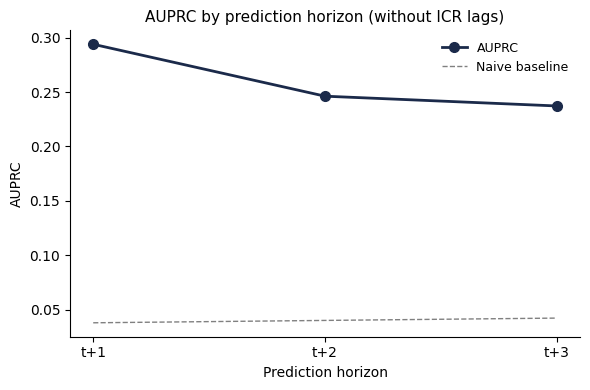

Saved: fig_ml_horizon_sweep.png


In [46]:
best_name = res_df["Test AUPRC"].idxmax()
print(f"Horizon sweep using: {best_name}")
print(f"ICR lags included : {INCLUDE_ICR_LAGS}\n")

horizon_results = []

for h in HORIZON_SWEEP:
    # Test year must be at most (max panel year - h) so the forward target exists
    max_panel_year = df["year"].max()
    valid_test_years = [y for y in TEST_YEARS if y + h <= max_panel_year]
    if not valid_test_years:
        # Fall back: use the latest year where forward target is available
        valid_test_years = [max_panel_year - h]

    df["target_h"] = df.groupby("bvd_id")[PRIMARY_ZOMBIE].shift(-h)
    ml_h = df[
        df["target_h"].notna() &
        df[BASE_FEATURES].notna().all(axis=1)
    ].copy()

    tr_h = ml_h[ml_h["year"].isin(TRAIN_YEARS)]
    vl_h = ml_h[ml_h["year"].isin(VAL_YEARS)]
    te_h = ml_h[ml_h["year"].isin(valid_test_years)]

    if len(te_h) == 0 or te_h["target_h"].nunique() < 2:
        print(f"  t+{h}: skipped — insufficient test data (years={valid_test_years})")
        continue

    Xtr, ytr = tr_h[ALL_FEATURES].values, tr_h["target_h"].values.astype(int)
    Xvl, yvl = vl_h[ALL_FEATURES].values, vl_h["target_h"].values.astype(int)
    Xte, yte = te_h[ALL_FEATURES].values, te_h["target_h"].values.astype(int)

    if HAS_XGB and best_name == "XGBoost":
        sp = (ytr == 0).sum() / (ytr == 1).sum()
        m = xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            scale_pos_weight=sp, random_state=42, verbosity=0
        )
        m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
    else:
        from sklearn.ensemble import RandomForestClassifier as RFC
        m = RFC(n_estimators=300, class_weight="balanced",
                max_depth=8, min_samples_leaf=20,
                n_jobs=-1, random_state=42)
        m.fit(Xtr, ytr)

    p_te = m.predict_proba(Xte)
    if p_te.shape[1] < 2:
        print(f"  t+{h}: skipped — single class in test slice")
        continue
    p_te = p_te[:, 1]
    auprc = average_precision_score(yte, p_te)
    roc   = roc_auc_score(yte, p_te)
    naive = yte.mean()

    horizon_results.append({
        "Horizon"      : f"t+{h}",
        "Test years"   : str(valid_test_years),
        "N obs"        : len(te_h),
        "Zombie rate"  : naive,
        "Test AUPRC"   : auprc,
        "Test ROC-AUC" : roc,
        "AUPRC / naive": auprc / naive,
    })
    print(f"  t+{h}: AUPRC={auprc:.3f}  ROC-AUC={roc:.3f}  "
          f"naive={naive:.3f}  ratio={auprc/naive:.1f}x  "
          f"(n={len(te_h):,}, test_years={valid_test_years})")

hz_df = pd.DataFrame(horizon_results).set_index("Horizon")
print("\n" + hz_df.round(3).to_string())
hz_df.to_csv(BASE_DIR / "nb5_horizon_sweep.csv")
print("Saved: nb5_horizon_sweep.csv")

# Plot only horizons that produced results
if len(hz_df) > 1:
    h_vals = [int(h.replace("t+", "")) for h in hz_df.index]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(h_vals, hz_df["Test AUPRC"], color=NAVY, lw=2, marker="o", markersize=7, label="AUPRC")
    ax.plot(h_vals, hz_df["Zombie rate"], color="grey", lw=1, ls="--", label="Naive baseline")
    ax.set_xticks(h_vals)
    ax.set_xticklabels([f"t+{h}" for h in h_vals])
    ax.set_xlabel("Prediction horizon", fontsize=10)
    ax.set_ylabel("AUPRC", fontsize=10)
    tag = "with ICR lags" if INCLUDE_ICR_LAGS else "without ICR lags"
    ax.set_title(f"AUPRC by prediction horizon ({tag})", fontsize=11)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_ml_horizon_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_ml_horizon_sweep.png")
else:
    print("Only one horizon produced results — plot skipped.")
    print("Panel ends in 2024: t+2 needs test observations from 2022, t+3 from 2021.")
    print("Consider setting TEST_YEARS = [2021, 2022] for the horizon sweep.")

## 11. Zombie entry as alternative target

Replaces the binary zombie status target with `zombie_entry` — a flag equal
to 1 only in the first year a firm receives the McGowan classification. This
removes from the positive class all firm-years where zombification is already
established, which are the rows where ICR lag leakage is most severe.

If the model performance drops substantially relative to the zombie status
target, the previous results were largely driven by already-classified firms
rather than genuine early detection.


In [47]:
# Build entry target: zombie_entry at t+1
df["entry_target"] = df.groupby("bvd_id")["zombie_entry"].shift(-1)

ml_entry = df[
    df["entry_target"].notna() &
    df[BASE_FEATURES].notna().all(axis=1)
].copy()

tr_e = ml_entry[ml_entry["year"].isin(TRAIN_YEARS)]
vl_e = ml_entry[ml_entry["year"].isin(VAL_YEARS)]
te_e = ml_entry[ml_entry["year"].isin(TEST_YEARS)]

print(f"Entry target dataset: {len(ml_entry):,} obs")
print(f"Entry rate (train): {tr_e['entry_target'].mean():.3%}")
print(f"Entry rate (test) : {te_e['entry_target'].mean():.3%}")

Xtr_e, ytr_e = tr_e[ALL_FEATURES].values, tr_e["entry_target"].values.astype(int)
Xvl_e, yvl_e = vl_e[ALL_FEATURES].values, vl_e["entry_target"].values.astype(int)
Xte_e, yte_e = te_e[ALL_FEATURES].values, te_e["entry_target"].values.astype(int)

if HAS_XGB:
    sp_e = (ytr_e == 0).sum() / max((ytr_e == 1).sum(), 1)
    m_entry = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        scale_pos_weight=sp_e, random_state=42, verbosity=0
    )
    m_entry.fit(Xtr_e, ytr_e, eval_set=[(Xvl_e, yvl_e)], verbose=False)
    entry_name = "XGBoost"
else:
    from sklearn.ensemble import RandomForestClassifier as RFC
    m_entry = RFC(n_estimators=300, class_weight="balanced",
                  max_depth=8, min_samples_leaf=20, n_jobs=-1, random_state=42)
    m_entry.fit(Xtr_e, ytr_e)
    entry_name = "Random Forest"

p_entry = m_entry.predict_proba(Xte_e)[:, 1]
entry_auprc = average_precision_score(yte_e, p_entry)
entry_roc   = roc_auc_score(yte_e, p_entry)
entry_naive = yte_e.mean()

print(f"\nEntry model ({entry_name}), ICR lags={INCLUDE_ICR_LAGS}:")
print(f"  Test AUPRC : {entry_auprc:.3f}  (naive baseline: {entry_naive:.3f})")
print(f"  Test ROC-AUC: {entry_roc:.3f}")
print(f"  AUPRC / naive ratio: {entry_auprc / entry_naive:.1f}x")

# Compare against zombie status target (primary model) for same features
status_auprc = res_df.loc[res_df["Test AUPRC"].idxmax(), "Test AUPRC"]
print(f"\n  Zombie status target AUPRC : {status_auprc:.3f}")
print(f"  Zombie entry  target AUPRC : {entry_auprc:.3f}")
print(f"  Drop: {status_auprc - entry_auprc:.3f} pp")


Entry target dataset: 294,569 obs
Entry rate (train): 1.371%
Entry rate (test) : 1.291%

Entry model (XGBoost), ICR lags=False:
  Test AUPRC : 0.093  (naive baseline: 0.013)
  Test ROC-AUC: 0.852
  AUPRC / naive ratio: 7.2x

  Zombie status target AUPRC : 0.304
  Zombie entry  target AUPRC : 0.093
  Drop: 0.211 pp


## 12. Summary


In [48]:
print("=" * 70)
print("NB5 — SUMMARY")
print("=" * 70)
print(f"Panel          : {len(ml_df):,} firm-years  | {ml_df['bvd_id'].nunique():,} unique firms")
print(f"Target         : zombie_mcgowan at t+{HORIZON}")
print(f"Include ICR lags: {INCLUDE_ICR_LAGS}")
print(f"Train years    : {TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]}")
print(f"Test years     : {TEST_YEARS}")
print(f"Features       : {len(ALL_FEATURES)}")
print(f"Imbalance      : 1:{1/ml_df['target'].mean():.0f}")
print()
best_name = res_df["Test AUPRC"].idxmax()
print(f"Best model     : {best_name}")
print(f"Test AUPRC     : {res_df.loc[best_name, 'Test AUPRC']:.4f}")
print(f"Test ROC-AUC   : {res_df.loc[best_name, 'Test ROC-AUC']:.4f}")
print(f"Test F1        : {res_df.loc[best_name, 'Test F1']:.4f}")
print(f"Naive AUPRC    : {y_test.mean():.4f}  (zombie prevalence)")
print()
print("Robustness checks:")
if "hz_df" in dir():
    print("  Horizon sweep  : see nb5_horizon_sweep.csv / fig_ml_horizon_sweep.png")
if "entry_auprc" in dir():
    print(f"  Zombie entry   : AUPRC = {entry_auprc:.3f}  (naive = {entry_naive:.3f})")
print()
print("Outputs:")
for f in sorted(FIG_DIR.glob("fig_ml*.png")):
    print(f"  {f.name}")
print("  nb5_ml_results.csv")
print("  nb5_horizon_sweep.csv")
if HAS_SHAP: print("  nb5_shap_importance.csv")
print("=" * 70)


NB5 — SUMMARY
Panel          : 294,569 firm-years  | 63,635 unique firms
Target         : zombie_mcgowan at t+1
Include ICR lags: False
Train years    : 2016–2021
Test years     : [2023, 2024]
Features       : 34
Imbalance      : 1:23

Best model     : XGBoost
Test AUPRC     : 0.3045
Test ROC-AUC   : 0.8744
Test F1        : 0.3578
Naive AUPRC    : 0.0381  (zombie prevalence)

Robustness checks:
  Horizon sweep  : see nb5_horizon_sweep.csv / fig_ml_horizon_sweep.png
  Zombie entry   : AUPRC = 0.093  (naive = 0.013)

Outputs:
  fig_ml_calibration.png
  fig_ml_curves.png
  fig_ml_horizon_sweep.png
  fig_ml_rolling.png
  fig_ml_shap.png
  nb5_ml_results.csv
  nb5_horizon_sweep.csv
  nb5_shap_importance.csv
